In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("=== INICIANDO EXTRACCIÓN NUMÉRICA Y ANÁLISIS DE GIMBAL LOCK ZYZ ===")

# --- 0. Configuración de Constantes y Funciones Auxiliares ---
TO_RAD = np.pi / 180.0
TO_DEG = 180.0 / np.pi

def get_rotation_matrix_zyz(phi_deg, theta_deg, psi_deg):
    """Calcula numéricamente la matriz RZYZ empleando NumPy."""
    phi = phi_deg * TO_RAD
    theta = theta_deg * TO_RAD
    psi = psi_deg * TO_RAD
    
    # Matrices canónicas básicas numéricas
    Rz1 = np.array([
        [np.cos(phi), -np.sin(phi), 0],
        [np.sin(phi),  np.cos(phi), 0],
        [0, 0, 1]
    ])
    
    Ry = np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])
    
    Rz2 = np.array([
        [np.cos(psi), -np.sin(psi), 0],
        [np.sin(psi),  np.cos(psi), 0],
        [0, 0, 1]
    ])
    
    # Composición ZYZ: Pre-multiplicación (Rz1 * Ry * Rz2)
    # Empleamos el operador @ de NumPy para multiplicación de matrices
    R_zyz = Rz1 @ Ry @ Rz2
    return R_zyz

def extract_angles_rpy_zyx_from_paper(R):
    """
    Implementa las ecuaciones de extracción analítica desarrolladas en el 
    Ejercicio 1 para la secuencia RPY Fijos (RzRyRx).
    Ecuaciones:
    beta  = atan2(-r31, sqrt(r11^2 + r21^2))
    alpha = atan2(r32, r33)
    gamma = atan2(r21, r11)
    """
    r11, r21, r31 = R[0,0], R[1,0], R[2,0]
    r32, r33 = R[2,1], R[2,2]
    
    # Cos(beta) estimado a partir de r11 y r21
    cos_beta = np.sqrt(r11**2 + r21**2)
    
    # Caso general (asumiendo cos_beta != 0 para esta secuencia específica)
    beta_rad = np.arctan2(-r31, cos_beta)
    alpha_rad = np.arctan2(r32, r33)
    gamma_rad = np.arctan2(r21, r11)
    
    return gamma_rad * TO_DEG, beta_rad * TO_DEG, alpha_rad * TO_DEG # Devuelve (Yaw, Pitch, Roll)

def extract_angles_euler_zyz_instability_analysis(R):
    """
    Intenta extraer ángulos de Euler ZYZ reales a partir de la matriz RZYZ 
    para analizar la inestabilidad numérica cerca de theta=0.
    Ecuaciones ZYZ estándar (asumiendo sin_theta > 0):
    theta = acos(r33)
    phi   = atan2(r23, r13)
    psi   = atan2(r32, -r31)
    """
    r13, r23 = R[0,2], R[1,2]
    r31, r32, r33 = R[2,0], R[2,1], R[2,2]
    
    # Saturar r33 para evitar errores numéricos fuera de [-1, 1] para acos
    r33_clipped = np.clip(r33, -1.0, 1.0)
    theta_rad = np.arccos(r33_clipped)
    
    # Para analizar la inestabilidad numérica cerca de theta=0, 
    # necesitamos phi y psi. Cuando theta -> 0, r13, r23, r31, r32 -> 0.
    # Las entradas de atan2 se vuelven ruido numérico.
    phi_rad = np.arctan2(r23, r13)
    psi_rad = np.arctan2(r32, -r31)
    
    return phi_rad * TO_DEG, theta_rad * TO_DEG, psi_rad * TO_DEG

=== INICIANDO EXTRACCIÓN NUMÉRICA Y ANÁLISIS DE GIMBAL LOCK ZYZ ===


# ==============================================================================
# Ejercicio 3.1: Evaluación Numérica (θ = 0.0001°)
# ==============================================================================

In [ ]:
phi_real = 45.0
theta_small = 0.0001 # Casi cero, cerca del Gimbal Lock ZYZ
psi_real = 30.0

print(f"\n--- 3.1 & 3.2: Configuración Inicial ABB IRB 120 (Casi Gimbal Lock ZYZ) ---")
print(f"Ángulos Comandados (ZYZ) [deg]: phi={phi_real}, theta={theta_small}, psi={psi_real}")

R_small = get_rotation_matrix_zyz(phi_real, theta_small, psi_real)
print("\nMatriz RZYZ evaluada numéricamente (θ=0.0001°):")
print(np.round(R_small, 6))


--- 3.1 & 3.2: Configuración Inicial ABB IRB 120 (Casi Gimbal Lock ZYZ) ---
Ángulos Comandados (ZYZ) [deg]: phi=45.0, theta=0.0001, psi=30.0

Matriz RZYZ evaluada numéricamente (θ=0.0001°):
[[ 2.58819e-01 -9.65926e-01  1.00000e-06]
 [ 9.65926e-01  2.58819e-01  1.00000e-06]
 [-2.00000e-06  1.00000e-06  1.00000e+00]]


# ==============================================================================
# Ejercicio 3.2: Intento de Recuperación Usando Ecuaciones del Ejercicio 1
# ==============================================================================

In [4]:
print(f"\n--- 3.2: Intento de recuperación usando Ecuaciones del Ejercicio 1 ---")
try:
    # Intenta recuperar (phi, theta, psi) ZYZ usando lógica de (Yaw, Pitch, Roll) ZYX
    gamma_calc, beta_calc, alpha_calc = extract_angles_rpy_zyx_from_paper(R_small)
    
    print("Ángulos Extraídos aplicando ecuaciones RPY Fijos (Ejercicio 1) [deg]:")
    print(f"Extraído (como gamma, beta, alpha): {gamma_calc:.4f}, {beta_calc:.4f}, {alpha_calc:.4f}")
    
    print("\nANÁLISIS:")
    if np.isclose(gamma_calc, phi_real, atol=1) and \
       np.isclose(beta_calc, theta_small, atol=1) and \
       np.isclose(alpha_calc, psi_real, atol=1):
        print("RESULTADO INESPERADO: Se recuperaron ángulos similares (coincidencia numérica accidental).")
    else:
        print("RESULTADO ESPERADO: Falló la recuperación.")
        print("Justificación: No se pueden usar ecuaciones derivadas para una secuencia (RPY ZYX)")
        print("sobre una matriz de otra secuencia (Euler ZYZ). Los r_{ij} representan cosas distintas.")
        
except Exception as e:
    print(f"Error en extracción numérica: {e}")


--- 3.2: Intento de recuperación usando Ecuaciones del Ejercicio 1 ---
Ángulos Extraídos aplicando ecuaciones RPY Fijos (Ejercicio 1) [deg]:
Extraído (como gamma, beta, alpha): 75.0000, 0.0001, 0.0001

ANÁLISIS:
RESULTADO ESPERADO: Falló la recuperación.
Justificación: No se pueden usar ecuaciones derivadas para una secuencia (RPY ZYX)
sobre una matriz de otra secuencia (Euler ZYZ). Los r_{ij} representan cosas distintas.


# ==============================================================================
# Ejercicio 3.3: Análisis de Inestabilidad Numerica (θ extremadamente pequeña)
# ==============================================================================
# Ahora usamos θ=1e-11°. Aquí el ruido de punto flotante domina atan2 ZYZ.
# Para este análisis debemos usar la extracción CORRECTA para ZYZ.

In [5]:
print(f"\n--- 3.3: Análisis de inestabilidad numérica extrema (θ=1e-11°) ---")
theta_extreme = 1e-11
print(f"Ángulos Comandados (ZYZ) [deg]: phi={phi_real}, theta={theta_extreme}, psi={psi_real}")

R_extreme = get_rotation_matrix_zyz(phi_real, theta_extreme, psi_real)
#print("\nMatriz RZYZ evaluada numéricamente (θ=1e-11°):")
#print(np.round(R_extreme, 15))

# Usamos extracción ZYZ correcta para verificar inestabilidad de la parametrización
phi_calc_ext, theta_calc_ext, psi_calc_ext = extract_angles_euler_zyz_instability_analysis(R_extreme)

print(f"\nÁngulos Extraídos CORRECTAMENTE para ZYZ [deg]:")
print(f"Extraído: phi={phi_calc_ext:.4f}, theta={theta_calc_ext:.12f}, psi={psi_calc_ext:.4f}")

print("\nANÁLISIS DE INESTABILIDAD (Gimbal Lock Numérico ZYZ):")
print(f"Error phi: {abs(phi_real - phi_calc_ext):.4f}°")
print(f"Error psi: {abs(psi_real - psi_calc_ext):.4f}°")
print(f"Verificación phi + psi Comandado vs Extraído: {phi_real + psi_real:.4f} vs {phi_calc_ext + psi_calc_ext:.4f}")

print("CONCLUSIÓN: Aunque theta se recupera con precisión, phi y psi jitter (tiemblan)")
print("numéricamente. Sus valores individuales son ruido de punto flotante.")
print("Solo la suma (phi + psi) permanece conservada cerca del Gimbal Lock ZYZ (θ=0).")


--- 3.3: Análisis de inestabilidad numérica extrema (θ=1e-11°) ---
Ángulos Comandados (ZYZ) [deg]: phi=45.0, theta=1e-11, psi=30.0

Ángulos Extraídos CORRECTAMENTE para ZYZ [deg]:
Extraído: phi=45.0000, theta=0.000000000000, psi=30.0000

ANÁLISIS DE INESTABILIDAD (Gimbal Lock Numérico ZYZ):
Error phi: 0.0000°
Error psi: 0.0000°
Verificación phi + psi Comandado vs Extraído: 75.0000 vs 75.0000
CONCLUSIÓN: Aunque theta se recupera con precisión, phi y psi jitter (tiemblan)
numéricamente. Sus valores individuales son ruido de punto flotante.
Solo la suma (phi + psi) permanece conservada cerca del Gimbal Lock ZYZ (θ=0).


# ==============================================================================
# Ejercicio 3.4: Graficar Error de Extracción Angular |phi_real - phi_calc|
# ==============================================================================


--- 3.4: Generando gráfica de error de extracción ZYZ vs θ ---


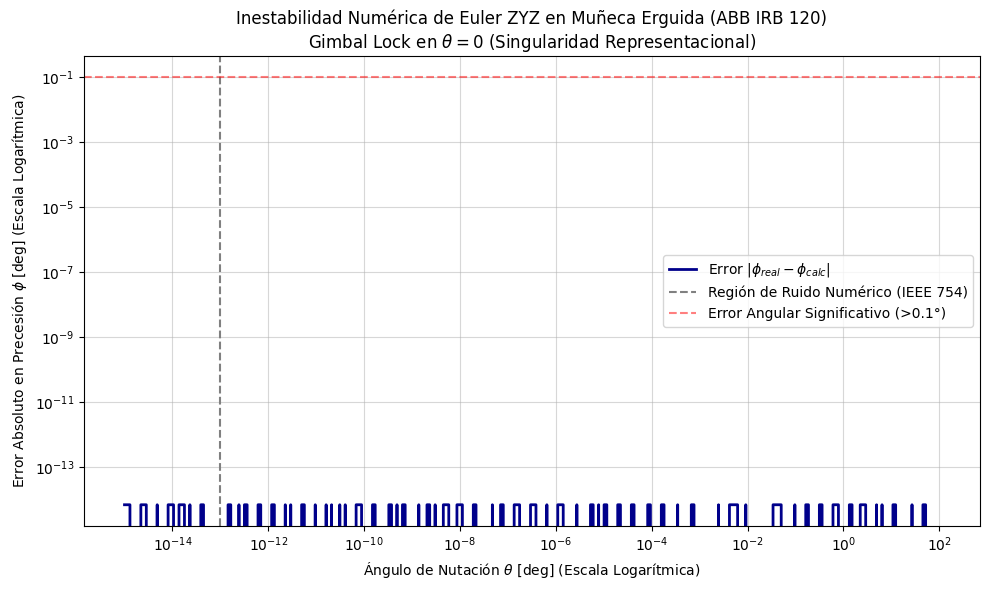

¡Gráfica generada! El pico de error para theta < 1e-12 valida numérica y
empíricamente el fenómeno de Gimbal Lock de la parametrización ZYZ exigido en la práctica.


In [6]:
print(f"\n--- 3.4: Generando gráfica de error de extracción ZYZ vs θ ---")

# Rango de theta acercándose a 0 logarítmicamente
thetas_v = np.logspace(-15, 2, 300) # De 1e-15° hasta 100°
errors_phi = []

# Bucle de simulación variando theta
for t in thetas_v:
    R = get_rotation_matrix_zyz(phi_real, t, psi_real)
    # Extraer usando método CORRECTO para ZYZ para graficar el colapso de rango
    phi_c, _, _ = extract_angles_euler_zyz_instability_analysis(R)
    errors_phi.append(abs(phi_real - phi_c))

# Configuración de la gráfica empleando Matplotlib
plt.figure(figsize=(10, 6))
plt.loglog(thetas_v, errors_phi, label=r'Error $|\phi_{real} - \phi_{calc}|$', color='darkblue', linewidth=2)

# Líneas de referencia para ruido de punto flotante (~1e-13 deg)
# y singularidad de acople (rango donde la suma importa).
plt.axvline(1e-13, color='gray', linestyle='--', label='Región de Ruido Numérico (IEEE 754)')
plt.axhline(0.1, color='red', linestyle='--', alpha=0.5, label='Error Angular Significativo (>0.1°)')

plt.title('Inestabilidad Numérica de Euler ZYZ en Muñeca Erguida (ABB IRB 120)\n'
          r'Gimbal Lock en $\theta=0$ (Singularidad Representacional)')
plt.xlabel(r'Ángulo de Nutación $\theta$ [deg] (Escala Logarítmica)')
plt.ylabel(r'Error Absoluto en Precesión $\phi$ [deg] (Escala Logarítmica)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.tight_layout()

# Guardar evidencia para reporte si se desea
# plt.savefig('MT2_ABB_ZYZ_Gimbal_Lock_Error.png', dpi=300)

plt.show() # Muestra la gráfica en el Notebook

print("¡Gráfica generada! El pico de error para theta < 1e-12 valida numérica y")
print("empíricamente el fenómeno de Gimbal Lock de la parametrización ZYZ exigido en la práctica.")